# 01 — CNN Training Application for Face vs Non-Face Classification

Dit notebook bouwt de **trainingsapplicatie** van het project.

## Doel

We trainen een CNN die images (64x64 pixels) classificeert als:

* **1 = face**
* **0 = non-face**

## Pipeline

1. Foto's laden uit mappen
2. Preprocessing en normalisatie
3. Train/validation/test split
4. Data augmentation
5. CNN bouwen
6. Model trainen
7. Hyperparameter tuning
8. Evalueren
9. Model opslaan voor de detectie-applicatie

## Verwachte mapstructuur

```text

FaceVsNonFaceProject/
├── data/
│   ├── faces/
│   └── non_faces/
└── models/

```

Later gaan we dit opgeslagen model gebruiken in de **main detection application**.

In [22]:
# 02 — IMPORTS

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn import model_selection
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras import Sequential
import tensorflow as tf

## Configuratie

Hier centraliseren we de belangrijkste parameters:
- beeldgrootte
- datasetlocaties
- random seed
- outputmap voor het model

In [23]:
IMG_SIZE = 64
RANDOM_STATE = 42

FACES_DIR = "data/faces"
NON_FACES_DIR = "data/non_faces"
MODEL_DIR = "models"
MODEL_PATH = os.path.join(MODEL_DIR, "face_classifier.keras")

os.makedirs(MODEL_DIR, exist_ok=True)

print("Model zal opgeslagen worden in:", MODEL_PATH)

Model zal opgeslagen worden in: models\face_classifier.keras


## Helperfunctie om afbeeldingen uit een map te laden

Deze functie:
- leest elke afbeelding
- resize naar `IMG_SIZE x IMG_SIZE`
- zet BGR om naar RGB
- koppelt een label aan elke afbeelding

In [24]:
def load_images_from_folder(folder, label, img_size=64):
    data = []
    labels = []

    if not os.path.exists(folder):
        raise FileNotFoundError(f"Map niet gevonden: {folder}")

    for filename in os.listdir(folder):
        path = os.path.join(folder, filename)

        img = cv2.imread(path)
        if img is None:
            continue

        img = cv2.resize(img, (img_size, img_size))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        data.append(img)
        labels.append(label)

    return data, labels

## Dataset laden

We combineren:
- `faces` → label 1
- `non_faces` → label 0

In [25]:
faces, face_labels = load_images_from_folder(FACES_DIR, label=1, img_size=IMG_SIZE)
non_faces, non_face_labels = load_images_from_folder(NON_FACES_DIR, label=0, img_size=IMG_SIZE)

X = np.array(faces + non_faces, dtype="float32")
y = np.array(face_labels + non_face_labels, dtype="int32")

print("Aantal voorbeelden:", len(X))
print("Vorm X:", X.shape)
print("Vorm y:", y.shape)
print("Aantal faces:", np.sum(y == 1))
print("Aantal non-faces:", np.sum(y == 0))

Aantal voorbeelden: 22899
Vorm X: (22899, 64, 64, 3)
Vorm y: (22899,)
Aantal faces: 14717
Aantal non-faces: 8182


## Voorbeeldafbeeldingen tonen

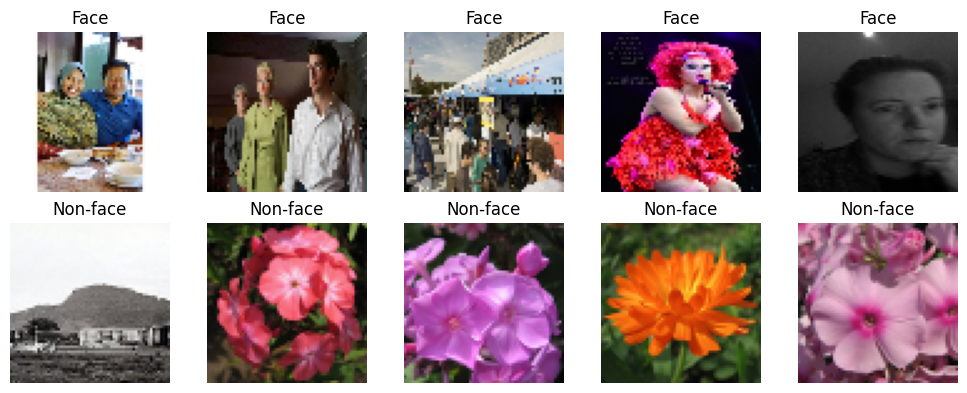

In [26]:
plt.figure(figsize=(10, 4))

for i in range(min(5, len(faces))):
    plt.subplot(2, 5, i + 1)
    plt.imshow(faces[i])
    plt.title("Face")
    plt.axis("off")

for i in range(min(5, len(non_faces))):
    plt.subplot(2, 5, i + 6)
    plt.imshow(non_faces[i])
    plt.title("Non-face")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Normalisatie

Pixelwaarden worden omgezet van `[0, 255]` naar `[0, 1]`.

In [27]:
X = X.astype("float32")

# Alleen schalen als X nog in [0, 255] zit
if X.max() > 1.0:
	X = X / 255.0

print("Na normalisatie - min:", X.min(), "max:", X.max())



Na normalisatie - min: 0.0 max: 1.0


## Train/validation/test split

Eerst scheiden we een testset af.
Daarna maken we uit de trainingsset nog een validatieset.

In [28]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train, X_val, y_train, y_val = model_selection.train_test_split(
    X_train, y_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (14655, 64, 64, 3) (14655,)
Validation: (3664, 64, 64, 3) (3664,)
Test: (4580, 64, 64, 3) (4580,)


## Verdeling van classes over train, validation en test

Deze grafiek toont of de verdeling tussen face en non-face ongeveer gelijk blijft in de verschillende datasets.

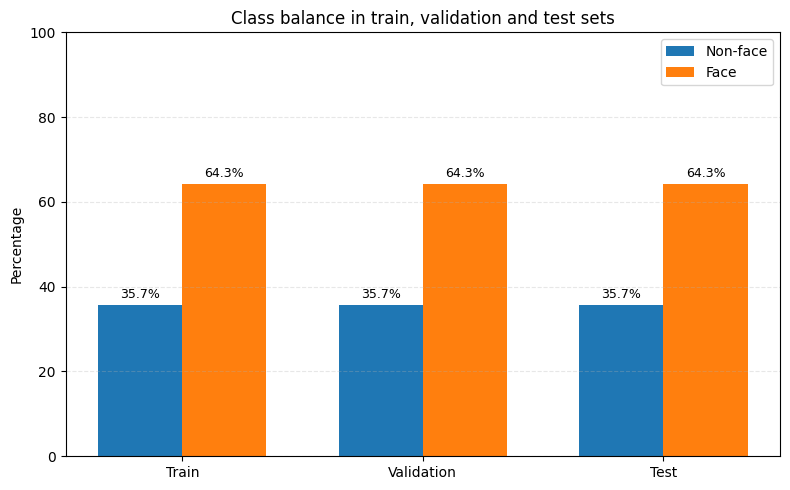

In [29]:
split_names = ["Train", "Validation", "Test"]
split_targets = [y_train, y_val, y_test]
class_names = ["Non-face", "Face"]

class_counts = np.array([
    np.bincount(targets, minlength=2) for targets in split_targets
])
class_percentages = class_counts / class_counts.sum(axis=1, keepdims=True) * 100

x = np.arange(len(split_names))
width = 0.35

plt.figure(figsize=(8, 5))
for index, class_name in enumerate(class_names):
    bars = plt.bar(
        x + (index - 0.5) * width,
        class_percentages[:, index],
        width=width,
        label=class_name
    )

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.8,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.xticks(x, split_names)
plt.ylabel("Percentage")
plt.ylim(0, 100)
plt.title("Class balance in train, validation and test sets")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## CNN bouwen

Architectuur:
- 3 convolutionele blokken
- pooling na elke convolutielaag
- dense laag
- dropout tegen overfitting
- sigmoid output voor binaire classificatie

In [30]:


model = Sequential([
    tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    Conv2D(32, (3,3), activation="relu"), MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"), MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation="relu"), MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

## Training starten

Met EarlyStopping vermijden we nodeloos doortrainen wanneer validatieverlies niet meer verbetert.

- monitor="val_loss"  → kijkt naar de validatiefout
- patience=3          → stopt als 3 epochs op rij geen verbetering
- min_delta=0.001     → minimale verandering om als verbetering te worden beschouwd
- restore_best_weights=True → zet model terug naar beste moment
- min_delta →4 voorkomt “micro noise stoppen”

In [31]:
# Stop training wanneer de validatiefout niet meer verbetert.
# restore_best_weights=True zet het model terug naar de beste epoch in plaats van de laatste te behouden.
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    min_delta=0.001,
    restore_best_weights=True
)

# Save de best presterende model tijdens training op basis van validatiefout.
# save_best_only=True werkt het bestand alleen bij wanneer een betere val_loss wordt gevonden.
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.h5",
    monitor="val_loss",
    save_best_only=True
)

# Train op de CNN op de trainingsset en evalueer het op de validatieset na elke epoch.
# De callbacks voorkomen onnodige epochs en houden een kopie van het beste model bij.
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7672 - loss: 0.4851

458/458 ━━━━━━━━━━━━━━━━━━━━ 52s 105ms/step - accuracy: 0.8222 - loss: 0.4065 - val_accuracy: 0.8693 - val_loss: 0.3108
Epoch 2/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.8860 - loss: 0.2912

458/458 ━━━━━━━━━━━━━━━━━━━━ 81s 102ms/step - accuracy: 0.8863 - loss: 0.2864 - val_accuracy: 0.8884 - val_loss: 0.2849
Epoch 3/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8912 - loss: 0.2628

458/458 ━━━━━━━━━━━━━━━━━━━━ 82s 101ms/step - accuracy: 0.9001 - loss: 0.2499 - val_accuracy: 0.9020 - val_loss: 0.2493
Epoch 4/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9081 - loss: 0.2281

458/458 ━━━━━━━━━━━━━━━━━━━━ 84s 105ms/step - accuracy: 0.9120 - loss: 0.2224 - val_accuracy: 0.9007 - val_loss: 0.2486
Epoch 5/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 79s 98ms/step - accuracy: 0.9219 - loss: 0.2008 - val_accuracy: 0.8971 - val_loss: 0.2544
Epoch 6/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9341 - loss: 0.1686

458/458 ━━━━━━━━━━━━━━━━━━━━ 84s 103ms/step - accuracy: 0.9307 - loss: 0.1767 - val_accuracy: 0.9230 - val_loss: 0.2148
Epoch 7/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9408 - loss: 0.1549

458/458 ━━━━━━━━━━━━━━━━━━━━ 82s 103ms/step - accuracy: 0.9419 - loss: 0.1503 - val_accuracy: 0.9236 - val_loss: 0.2094
Epoch 8/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 82s 103ms/step - accuracy: 0.9503 - loss: 0.1297 - val_accuracy: 0.9203 - val_loss: 0.2494
Epoch 9/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 82s 103ms/step - accuracy: 0.9634 - loss: 0.0944 - val_accuracy: 0.9222 - val_loss: 0.2647
Epoch 10/15
458/458 ━━━━━━━━━━━━━━━━━━━━ 47s 103ms/step - accuracy: 0.9689 - loss: 0.0816 - val_accuracy: 0.9192 - val_loss: 0.2559


## Extra info: hyperparameter tuning met GridSearchCV

Deze stap is **informatief** en hoort niet bij de standaard trainingsflow van dit notebook.

In dit notebook trainen we het CNN rechtstreeks met een vaste architectuur en evalueren we daarna op de testset.

Je kan later eventueel `GridSearchCV` en `SciKeras` gebruiken om automatisch combinaties van hyperparameters te vergelijken, bijvoorbeeld:

- aantal filters
- dropout
- batch size
- epochs
- aantal neuronen in de dense laag

Voor deze versie voeren we die zoekstap niet uit, zodat de training eenvoudiger en sneller blijft.

## Leercurves visualiseren

bewijst geen overfitting, correcte training

- Regularisatie techniek
- Overfitting controle
- Automatische model selectie
- Efficiënte training

We kunnen eventueel Early stopping gebruiken om overfitting te voorkomen door de training te stoppen zodra de validatiefout niet meer verbetert, en herstelt automatisch de beste modelgewichten."

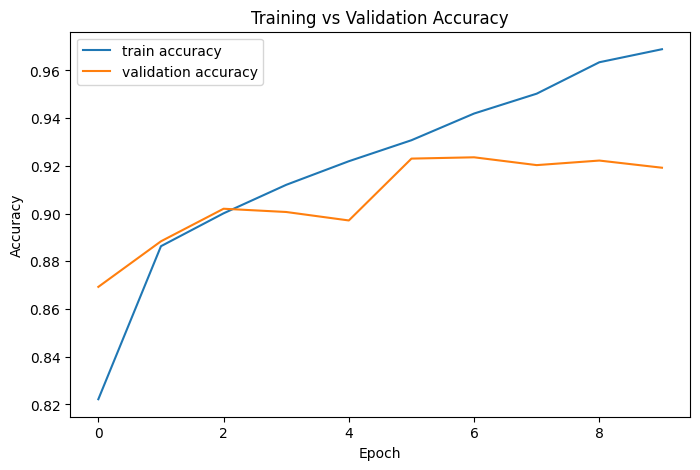

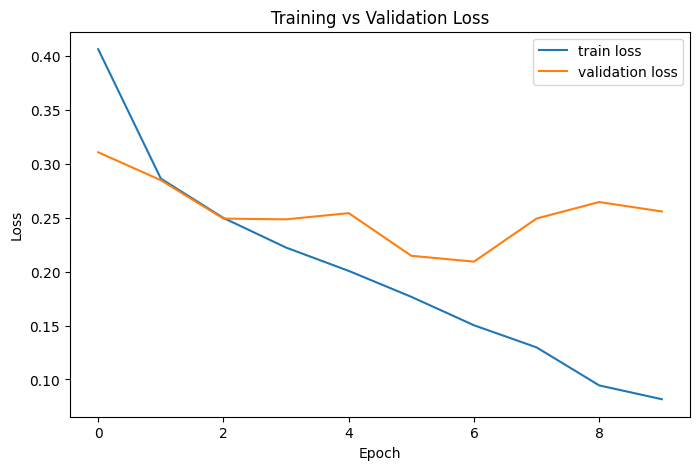

In [32]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Evaluatie op de testset

Test loss: 0.2191
Test accuracy: 0.9155
              precision    recall  f1-score   support

           0       0.88      0.89      0.88      1636
           1       0.94      0.93      0.93      2944

    accuracy                           0.92      4580
   macro avg       0.91      0.91      0.91      4580
weighted avg       0.92      0.92      0.92      4580



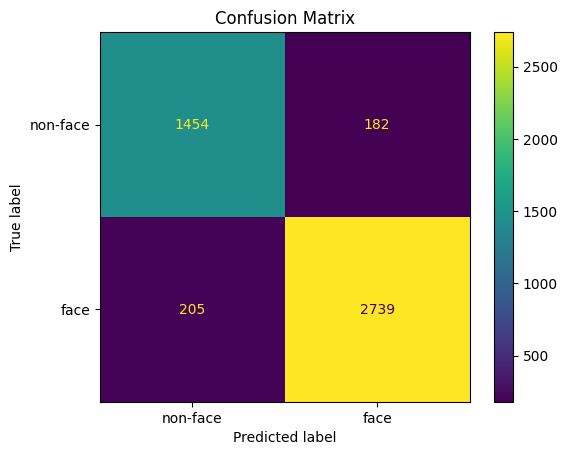

In [33]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

y_prob = model.predict(X_test, verbose=0)
y_pred = (y_prob > 0.5).astype(int).ravel()

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["non-face", "face"])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

## Model opslaan

Dit bestand wordt later geladen door de **main detection application**.

In [34]:
model.save(MODEL_PATH)
print("Model opgeslagen in:", MODEL_PATH)

Model opgeslagen in: models\face_classifier.keras


## Besluit

In dit notebook hebben we:
- de dataset geladen
- een CNN getraind
- de classifier geëvalueerd
- het model opgeslagen

De volgende stap is dat opgeslagen model gebruiken in een applicatie die gezichten in een grotere afbeelding detecteert.